<a href="https://colab.research.google.com/github/aaryachauhan123/AI-ML-Learning/blob/main/logisitic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

In [ ]:
print(data.keys(),"\n")


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']) 



In [ ]:
print(data.data.shape,"\n")

(569, 30) 



In [ ]:
print(data.feature_names,"\n")

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension'] 



In [ ]:
print(data.target_names)

['malignant' 'benign']


# Conver to dataframe

In [ ]:
df = pd.DataFrame(data.data, columns=data.feature_names)

In [ ]:
df['target'] = data.target

In [ ]:
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
print(df.info(),"\n")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [ ]:
df.drop_duplicates(inplace=True)

# split dataset

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Training of logistic regression model

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

# Prediction of model

In [ ]:
y_pred = model.predict(X_test)

importing necessary libraries for confusion matrix   accuracy score, precision score, recall score and f1 score

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score



In [ ]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[39  4]
 [ 1 70]]


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.956140350877193


In [ ]:
print("Precision:", precision_score(y_test, y_pred))

Precision: 0.9459459459459459


In [ ]:
print("Recall:", recall_score(y_test, y_pred))

Recall: 0.9859154929577465


In [ ]:
print("F1 Score:", f1_score(y_test, y_pred))

F1 Score: 0.9655172413793104


In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]
# y_prob will contain a single array of probabilities for each sample belonging to the positive class.

# Threshold at 0.3

In [ ]:

y_pred_03 = np.where(y_prob >= 0.3, 1, 0)

print("Threshold 0.3")
print("Accuracy:", accuracy_score(y_test, y_pred_03))
print("Precision:", precision_score(y_test, y_pred_03))
print("Recall:", recall_score(y_test, y_pred_03))
print("F1:", f1_score(y_test, y_pred_03))

Threshold 0.3
Accuracy: 0.956140350877193
Precision: 0.9459459459459459
Recall: 0.9859154929577465
F1: 0.9655172413793104


Accuracy (0.9561): This is the proportion of total predictions that were correct. In this case, about 95.6% of the breast cancer diagnoses (malignant or benign) made by the model were correct.  

Precision (0.9459): This metric tells you, among all the cases the model predicted as positive (e.g., 'benign' if 1 is benign, or 'malignant' if 1 is malignant - let's assume 1 corresponds to benign based on target_names output ['malignant' 'benign'] where 0 is malignant and 1 is benign), what percentage were actually positive. A precision of 0.9459 means that about 94.6% of the cases predicted as 'benign' were indeed 'benign'.  

Recall (0.9859): Also known as sensitivity, recall tells you, among all the actual positive cases in your test set, what percentage the model correctly identified. A recall of 0.9859 means that the model correctly identified about 98.6% of all actual 'benign' cases.  

F1 Score (0.9655): This is the harmonic mean of precision and recall. It provides a single score that balances both precision and recall. An F1 score of 0.9655 indicates a strong balance between the model's ability to avoid false positives and false negatives for the positive class

# Threshold at 0.9

In [ ]:
y_pred_09 = np.where(y_prob >= 0.9, 1, 0)
print("Threshold 0.9")
print("Accuracy:", accuracy_score(y_test, y_pred_09))
print("Precision:", precision_score(y_test, y_pred_09))
print("Recall:", recall_score(y_test, y_pred_09))
print("F1:", f1_score(y_test, y_pred_09))

Threshold 0.9
Accuracy: 0.9385964912280702
Precision: 1.0
Recall: 0.9014084507042254
F1: 0.9481481481481482


# here in 0.9 compare to threshhold 0.3
**Accuracy** slightly decreased from 0.9561 to 0.9386.  
**Precision** significantly increased from 0.9459 to 1.0, meaning all positive predictions were correct.  
**Recall** decreased from 0.9859 to 0.9014, indicating fewer actual positive cases were identified.  
**F1 Score** also decreased from 0.9655 to 0.9481, reflecting the trade-off between precision and recall.

# Roc curve

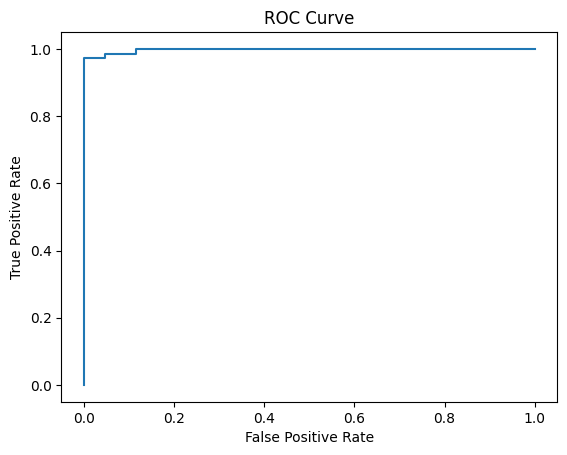

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

Final Understanding

Threshold 0.3 → High Recall, Low Precision

Threshold 0.9 → High Precision, Low Recall

0.5 → Balanced

** In cancer detection:**
 We prefer higher recall (don’t miss patients)

# precision recall curve

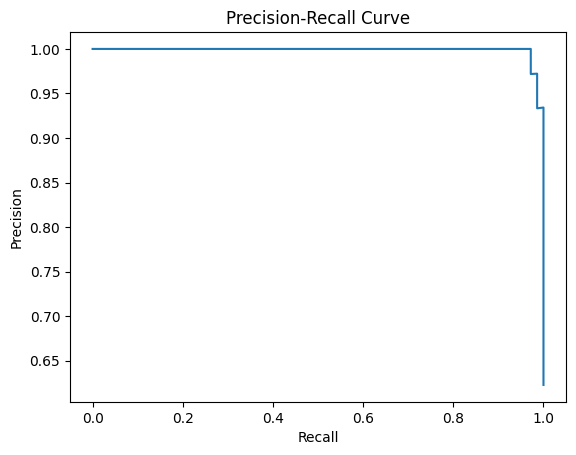

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# compute precision & recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# plot
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# What do we understand from the Precision–Recall Curve?

1. Trade-off between Precision & Recall

As Recall increases, Precision usually decreases

As Precision increases, Recall decreases

**Meaning:**

We can’t maximize both at the same time  

 Real-Life (Our Case: Cancer Detection)

**Recall** = how many actual cancer patients you detect

**Precision** = how many predicted patients are actually cancer

So:

**High Recall** → you detect almost all patients (good ✅)

But **Precision** may drop → more false alarms (acceptable ⚠️)